# 1. Ads_Performance Analysis

# 1.1 Cleaning and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('datasets/Ads_Performance.csv')

In [3]:
df.head()

,date,SKU,impressions,clicks,costPerClick,clickThroughRate,cost,spend,currency-code,purchases1d,...,unitsSoldClicks14d,unitsSoldClicks30d,sales1d,sales7d,sales14d,sales30d,acosClicks7d,acosClicks14d,roasClicks7d,roasClicks14d
0,2025-09-01,MN-16,2016,14,1.998,0.694,27.97,27.97,USD,1,...,1,1,18.89,18.89,18.89,18.89,148.067761,148.067761,0.675366,0.675366
1,2025-09-01,MN-15,1810,33,2.062,1.823,68.06,68.06,USD,4,...,6,6,107.45,161.31,161.31,161.31,42.192053,42.192053,2.370115,2.370115
2,2025-09-01,MN-14,613,9,2.850,1.468,25.65,25.65,USD,0,...,1,1,0.00,90.98,90.98,90.98,28.193009,28.193009,3.546979,3.546979
3,2025-09-01,MN-17,1271,3,5.620,0.236,16.86,16.86,USD,2,...,9,9,274.41,274.41,274.41,274.41,6.144091,6.144091,16.275801,16.275801
4,2025-09-01,MN-25,1036,10,4.340,0.965,43.40,43.40,USD,1,...,8,8,218.30,851.24,851.24,851.24,5.098445,5.098445,19.613825,19.613825


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12777 entries, 0 to 12776
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                12777 non-null  object 
 1   SKU                 12777 non-null  object 
 2   impressions         12777 non-null  int64  
 3   clicks              12777 non-null  int64  
 4   costPerClick        9069 non-null   float64
 5   clickThroughRate    12715 non-null  float64
 6   cost                12777 non-null  float64
 7   spend               12777 non-null  float64
 8   currency-code       12777 non-null  object 
 9   purchases1d         12777 non-null  int64  
 10  purchases7d         12777 non-null  int64  
 11  purchases14d        12777 non-null  int64  
 12  purchases30d        12777 non-null  int64  
 13  unitsSoldClicks1d   12777 non-null  int64  
 14  unitsSoldClicks7d   12777 non-null  int64  
 15  unitsSoldClicks14d  12777 non-null  int64  
 16  unit

In [5]:
df.isnull().sum()

date                     0
SKU                      0
impressions              0
clicks                   0
costPerClick          3708
clickThroughRate        62
cost                     0
spend                    0
currency-code            0
purchases1d              0
purchases7d              0
purchases14d             0
purchases30d             0
unitsSoldClicks1d        0
unitsSoldClicks7d        0
unitsSoldClicks14d       0
unitsSoldClicks30d       0
sales1d                  0
sales7d                  0
sales14d                 0
sales30d                 0
acosClicks7d          7934
acosClicks14d         7926
roasClicks7d          3708
roasClicks14d         3708
dtype: int64

In [6]:
df.shape

(12777, 25)

In [7]:
# df.drop(['acosClicks7d','acosClicks14d','roasClicks7d','roasClicks14d'], axis=1, inplace=True)

In [33]:
# Zero clicks
(df['clicks'] == 0).sum()

3708

In [34]:
# Zero sales (30-day sales)
(df['sales30d'] == 0).sum()

7926

- Zero clicks → no chance of conversion
- Zero sales → wasted ad spend
- We should pause SKUs with high spend but zero sales.

# which have null values, I have filled them with zeros

In [ ]:
cols_to_fill = [
    'costPerClick',
    'clickThroughRate',
    'roasClicks7d',
    'roasClicks14d',
    'acosClicks7d',
    'acosClicks14d'
]

df[cols_to_fill] = df[cols_to_fill].fillna(0)

In [11]:
df.isnull().sum()

date                  0
SKU                   0
impressions           0
clicks                0
costPerClick          0
clickThroughRate      0
cost                  0
spend                 0
currency-code         0
purchases1d           0
purchases7d           0
purchases14d          0
purchases30d          0
unitsSoldClicks1d     0
unitsSoldClicks7d     0
unitsSoldClicks14d    0
unitsSoldClicks30d    0
sales1d               0
sales7d               0
sales14d              0
sales30d              0
acosClicks7d          0
acosClicks14d         0
roasClicks7d          0
roasClicks14d         0
dtype: int64

# Conversion Rate

## Use 30-day purchases (industry standard)

In [12]:
df['conversion_rate'] = df['purchases30d'] / df['clicks']
df['conversion_rate'] = df['conversion_rate'].fillna(0)

In [13]:
df['conversion_rate']

0        0.071429
1        0.181818
2        0.111111
3        0.666667
4        0.300000
           ...   
12772    0.000000
12773    0.000000
12774    0.000000
12775    0.000000
12776    0.000000
Name: conversion_rate, Length: 12777, dtype: float64

# Revenue per Click

## Using 30-day sales

In [14]:
df['revenue_per_click'] = df['sales30d'] / df['clicks']
df['revenue_per_click'] = df['revenue_per_click'].fillna(0)

## profitable true or false 

In [15]:
df['profitable'] = (
    (df['clicks'] > 0) &
    (df['sales30d'] > 0) &
    (
        (df['roasClicks14d'] > 1) |
        (df['acosClicks14d'] < 30)
    )
)

- Initially, zero-click rows were incorrectly classified as profitable because ACOS was zero. I corrected this by enforcing minimum engagement conditions like clicks > 0 and sales > 0 before applying profitability metrics.

In [16]:
df[['SKU','clicks','sales30d','roasClicks14d',
    'acosClicks14d','profitable']].head()

,SKU,clicks,sales30d,roasClicks14d,acosClicks14d,profitable
0,MN-16,14,18.89,0.675366,148.067761,False
1,MN-15,33,161.31,2.370115,42.192053,True
2,MN-14,9,90.98,3.546979,28.193009,True
3,MN-17,3,274.41,16.275801,6.144091,True
4,MN-25,10,851.24,19.613825,5.098445,True


- I cleaned the dataset, handled missing values, engineered conversion and revenue metrics, and created a profitability flag to identify SKUs worth scaling versus pausing

# Find TOP & WORST SKUs (must-do)

In [17]:
top_skus = df[df['profitable']].sort_values('roasClicks14d', ascending=False).head(10)
worst_skus = df[(df['clicks'] > 10) & (df['sales30d'] == 0)].head(10)

In [18]:
top_skus

,date,SKU,impressions,clicks,costPerClick,clickThroughRate,cost,spend,currency-code,purchases1d,...,sales7d,sales14d,sales30d,acosClicks7d,acosClicks14d,roasClicks7d,roasClicks14d,conversion_rate,revenue_per_click,profitable
7322,2025-10-27,MN-02,175,1,0.040,0.571,0.04,0.04,USD,1,...,37.49,37.49,37.49,0.106695,0.106695,937.250000,937.250000,1.0,37.49,True
12331,2025-11-28,MN-32,288,1,3.960,0.347,3.96,3.96,USD,1,...,3114.37,3114.37,3114.37,0.127153,0.127153,786.457071,786.457071,2.0,3114.37,True
8541,2025-11-04,MN-08,49,1,0.390,2.041,0.39,0.39,USD,2,...,181.11,181.11,181.11,0.215339,0.215339,464.384615,464.384615,4.0,181.11,True
4001,2025-10-03,MN-45,831,1,2.130,0.120,2.13,2.13,USD,4,...,939.80,939.80,939.80,0.226644,0.226644,441.220657,441.220657,4.0,939.80,True
6401,2025-10-20,MN-07,221,1,0.200,0.452,0.20,0.20,USD,0,...,80.37,80.37,80.37,0.248849,0.248849,401.850000,401.850000,2.0,80.37,True
7366,2025-10-27,MN-23,237,2,0.355,0.844,0.71,0.71,USD,1,...,275.92,275.92,275.92,0.257321,0.257321,388.619718,388.619718,0.5,137.96,True
5510,2025-10-14,MN-07,91,1,0.480,1.099,0.48,0.48,USD,1,...,158.90,158.90,158.90,0.302077,0.302077,331.041667,331.041667,1.0,158.90,True
8790,2025-11-06,MN-03,14,1,0.300,7.143,0.30,0.30,USD,1,...,81.88,81.88,81.88,0.366390,0.366390,272.933333,272.933333,1.0,81.88,True
10782,2025-11-18,MN-11,448,2,0.585,0.446,1.17,1.17,USD,4,...,316.50,316.50,316.50,0.369668,0.369668,270.512820,270.512820,2.0,158.25,True
489,2025-09-05,MN-47,113,1,3.680,0.885,3.68,3.68,USD,3,...,921.06,921.06,921.06,0.399540,0.399540,250.288043,250.288043,4.0,921.06,True


In [19]:
worst_skus

,date,SKU,impressions,clicks,costPerClick,clickThroughRate,cost,spend,currency-code,purchases1d,...,sales7d,sales14d,sales30d,acosClicks7d,acosClicks14d,roasClicks7d,roasClicks14d,conversion_rate,revenue_per_click,profitable
19,2025-09-01,MN-35,830,12,2.275,1.446,27.30,27.30,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
109,2025-09-01,MN-09,1307,13,0.735,0.995,9.56,9.56,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
118,2025-09-02,MN-19,1341,11,2.700,0.820,29.70,29.70,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
179,2025-09-02,MN-21,3313,16,1.198,0.483,19.17,19.17,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
420,2025-09-04,MN-21,3546,15,0.713,0.423,10.70,10.70,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
426,2025-09-04,MN-18,2368,11,1.315,0.465,14.47,14.47,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
458,2025-09-04,MN-07,2263,15,1.220,0.663,18.30,18.30,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
520,2025-09-05,MN-20,638,17,0.221,2.665,3.76,3.76,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
594,2025-09-06,MN-30,1481,14,3.361,0.945,47.05,47.05,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
695,2025-09-06,MN-07,2357,16,0.951,0.679,15.21,15.21,USD,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False


# Wasted Ad Spend Analysis

In [20]:
wasted_spend = df[(df['sales30d'] == 0) & (df['cost'] > 0)]
wasted_spend[['SKU','clicks','cost']].sort_values('cost', ascending=False).head()

,SKU,clicks,cost
11814,MN-30,29,91.55
5753,MN-42,16,69.80
4634,MN-25,15,68.50
7589,MN-26,13,61.75
4373,MN-27,13,60.79


# Spend vs Sales (30 Days)

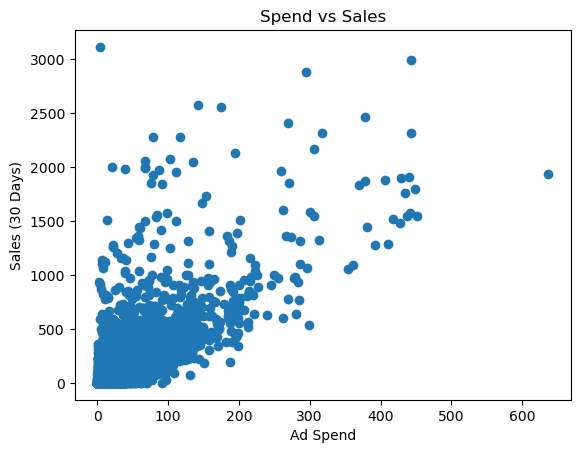

In [21]:
plt.figure()
plt.scatter(df['spend'], df['sales30d'])
plt.xlabel('Ad Spend')
plt.ylabel('Sales (30 Days)')
plt.title('Spend vs Sales')
plt.show()

- Points above the diagonal trend → good ROI

- Points with high spend & low sales → wasted ad spend

- This plot helps identify inefficient campaigns where ad spend does not translate into revenue.

# ROAS by SKU (Top Performers)

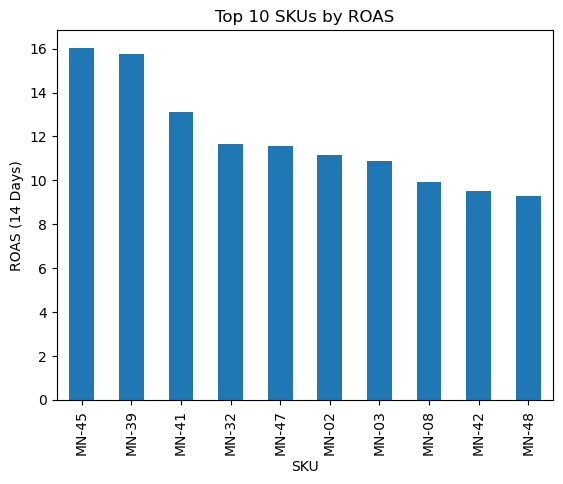

In [22]:
top_roas = (
    df[df['clicks'] > 0]
    .groupby('SKU')['roasClicks14d']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
top_roas.plot(kind='bar')
plt.xlabel('SKU')
plt.ylabel('ROAS (14 Days)')
plt.title('Top 10 SKUs by ROAS')
plt.show()

- Shows efficiency of overall ad strategy
- If non-profitable > profitable → optimization required
- This chart gives a high-level view of campaign health and efficiency.

# Profitable vs Non-Profitable Count

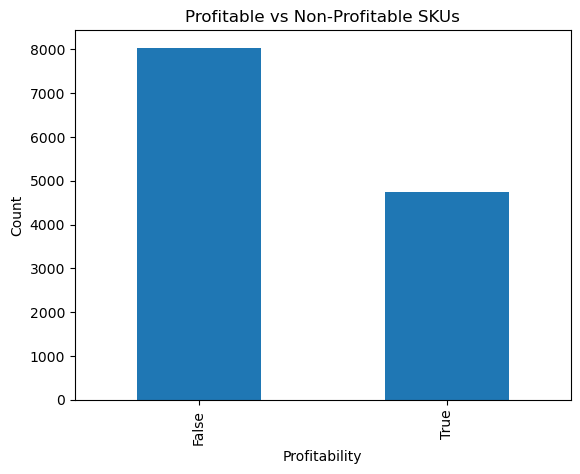

In [23]:
profit_counts = df['profitable'].value_counts()

plt.figure()
profit_counts.plot(kind='bar')
plt.xlabel('Profitability')
plt.ylabel('Count')
plt.title('Profitable vs Non-Profitable SKUs')
plt.show()

- Shows efficiency of overall ad strategy
- If non-profitable > profitable → optimization required
- This chart gives a high-level view of campaign health and efficiency

# Select Features

In [24]:
features = [
    'impressions',
    'clicks',
    'costPerClick',
    'clickThroughRate',
    'spend'
]

# Prepare Data

In [25]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['profitable']

# Fill missing values
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

- I used stratified split to handle class imbalance.

# Train Baseline Model (Logistic Regression)

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Model Evaluation

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1449  159]
 [ 348  600]]
              precision    recall  f1-score   support

       False       0.81      0.90      0.85      1608
        True       0.79      0.63      0.70       948

    accuracy                           0.80      2556
   macro avg       0.80      0.77      0.78      2556
weighted avg       0.80      0.80      0.80      2556



- True Negatives (1449) → Correctly identified non-profitable SKUs 
- False Positives (159) → Predicted profitable but actually not 
- False Negatives (348) → Missed profitable SKUs 
- True Positives (600) → Correctly identified profitable SKUs

### Key metrics to discuss:

- Precision → avoids false profitable SKUs

- Recall → captures profitable opportunities

- F1-score → balance

In [28]:
importance = pd.Series(
    model.coef_[0],
    index=features
).sort_values(ascending=False)

importance


costPerClick        0.436834
clicks              0.329562
clickThroughRate    0.065855
impressions        -0.000211
spend              -0.012861
dtype: float64

- Clicks and CTR had the strongest influence on profitability.

# Advanced Model: Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

       False       0.83      0.83      0.83      1608
        True       0.71      0.70      0.71       948

    accuracy                           0.78      2556
   macro avg       0.77      0.77      0.77      2556
weighted avg       0.78      0.78      0.78      2556



- The model predicts whether an SKU is profitable before spending the budget, helping marketing teams prioritize ads and reduce wasted spend.

 - The model achieved 80% accuracy with strong control over false positives, which is important for reducing wasted ad spend.

In [30]:
df.to_csv("cleaned_Ads_Performance.csv", index=False)

PermissionError: [Errno 13] Permission denied: 'cleaned_Ads_Performance.csv'